Example of how to parse the files and load data in dataframes.

In [1]:
#%pip install matplotlib

import os
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [2]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

/Users/filipnordqvist/Documents/GitHub/Examensarbete/data


In [3]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [4]:
#%pip install pandas

import pandas as pd

# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [5]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_12
Loading test:  12_5
Loading test:  12_2
Loading test:  12_3
Loading test:  12_4
Loading test:  12_10
Loading test:  12_11
Loading test:  12_1
Loading test:  12_6
Loading test:  12_8
Loading test:  12_9
Loading test:  12_7
Loading test:  12_0
Loading test:  12_13
Loading test:  12_12
---------------------------------------------
Loading walking data for subject:  subject_15
---------------------------------------------
Loading walking data for subject:  subject_14
Loading test:  14_9
Loading test:  14_0
Loading test:  14_7
Loading test:  14_6
Loading test:  14_1
Loading test:  14_8
Loading test:  14_14
Loading test:  14_13
Loading test:  14_12
Loading test:  14_4
Loading test:  14_3
Loading test:  14_2
Loading test:  14_5
Loading test:  14_10
Loading test:  14_11
---------------------------------------------
Loading walking data for subject:  subject_13
Loading test:  13_11
Loading test:  13_10
L

In [6]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  12_5
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023
Motion:     Unnamed: 0     ms    accelX    accelY    accelZ  accelWithGX  accelWithGY  \
0           0  301.0  0.438315 -0.063984 -0.070899    -0.022308     1.661179   
1           1  326.0  0.498090 -0.201496  0.016141    -0.035461     1.648026   
2           2  344.0  0.458053 -0.219058 -0.166888    -0.171860     1.747330   
3           3  366.0  0.212662 -0.051397 -0.305197    -0.256805     1.845428   
4           4  383.0  0.212662 -0.051397 -0.305197    -0.429092     1.931564   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0     9.639145      2.197900     3.448972      7.877995        16  
1     9.442932      5.656489     1.173263      5.241214        16  
2     9.349625      6.130341     0.611111      3.747971        16  
3     9.267059      7.771335     2.842233      4.861783        16  
4     9.143829 

In [7]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

In [8]:
for i, test in enumerate(selection):
    print(f"Attributes of selection[{i}]:")
    print(vars(test))  # or print(test.__dict__)
    print("-" * 50)

Attributes of selection[0]:
{'filename': '12_5', 'events':    Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023, 'motion':        Unnamed: 0        ms    accelX    accelY    accelZ  accelWithGX  \
0               0     301.0  0.438315 -0.063984 -0.070899    -0.022308   
1               1     326.0  0.498090 -0.201496  0.016141    -0.035461   
2               2     344.0  0.458053 -0.219058 -0.166888    -0.171860   
3               3     366.0  0.212662 -0.051397 -0.305197    -0.256805   
4               4     383.0  0.212662 -0.051397 -0.305197    -0.429092   
...           ...       ...       ...       ...       ...          ...   
13341       13341  241052.0  0.394181 -0.649407 -0.898338    -0.170654   
13342       13342  241070.0  0.453704 -0.624669 -1.077359    -0.170654   
13343       13343  241089.0  0.442678 -0.538984 -1.089510    -0.801163   
13344       13344  241105.0 -0.196482 -0.706071 -0.146003    -0.981827   
13345     

In [11]:
import math

all_tests = []

# Proceed with the filtered selection
for test in selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']

Total distance traveled for 12_5: 261.31 meters
Total distance traveled for 12_2: 536.30 meters
Total distance traveled for 12_3: 465.94 meters
Total distance traveled for 12_4: 331.33 meters
Total distance traveled for 12_10: 350.25 meters
Total distance traveled for 12_11: 267.03 meters
Total distance traveled for 12_1: 402.64 meters
Total distance traveled for 12_6: 255.49 meters
Total distance traveled for 12_8: 326.20 meters
Total distance traveled for 12_9: 238.42 meters
Total distance traveled for 12_7: 239.40 meters
Total distance traveled for 12_0: 502.63 meters
Total distance traveled for 12_13: 143.71 meters
Total distance traveled for 12_12: 198.97 meters
Total distance traveled for 14_9: 1152.09 meters
Total distance traveled for 14_0: 1066.28 meters
Total distance traveled for 14_7: 1111.73 meters
Total distance traveled for 14_6: 1265.65 meters
Total distance traveled for 14_1: 1132.85 meters
Total distance traveled for 14_8: 1389.72 meters
Total distance traveled for 14

In [10]:
results = []


def create_dataset_simple(data, time_step=10):
    X, y = [], []
    distances = np.cumsum(data[:, 0])  # anta att kolumn 0 = speed_mps
    for i in range(len(data) - time_step - 360):  # 360 sekunder framåt
        X.append(data[i:(i + time_step), :])
        future_distance = np.sum(data[i + time_step: i + time_step + 360, 0])
        y.append(future_distance)
    return np.array(X), np.array(y)


for test in selection:
    positions_data = test.positions.copy()

    # Förbehandling
    positions_data['time_s'] = (
        positions_data['ms'] - positions_data['ms'].min()) / 1000
    distances = [0] + [
        crowDist(positions_data.iloc[i - 1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances
    positions_data['delta_time_s'] = positions_data['time_s'].diff().clip(
        lower=0.1)
    positions_data['speed_mps'] = positions_data['distance_m'] / \
        positions_data['delta_time_s']

    positions_data = positions_data[['speed_mps']].dropna()
    scaled_data = MinMaxScaler().fit_transform(positions_data.values)

    X, y = create_dataset_simple(scaled_data, time_step=10)
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

    # Modell
    from tensorflow.keras import Input

    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))
    model.add(GRU(units=64))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mean_absolute_error')
    model.fit(X, y, epochs=10, batch_size=32, verbose=0)

    # Prediktion från senaste fönstret
    input_seq = scaled_data[-10:].reshape(1, 10, 1)
    predicted_scaled = model.predict(input_seq, verbose=0)[0][0]

    # Omvandla till faktisk distans
    mean_speed = positions_data['speed_mps'].mean()
    predicted_distance = predicted_scaled * 360 * mean_speed  # grovskattning
    actual_distance = np.sum(positions_data['speed_mps'].values[:360])

    mse = mean_squared_error([actual_distance], [predicted_distance])
    rmse = math.sqrt(mse)

    results.append({
        'subject': test.filename,
        'mse': mse,
        'rmse': rmse,
        'actual_distance': actual_distance,
        'predicted_distance': predicted_distance
    })

    print(f"{test.filename} → RMSE: {rmse:.2f} m | Actual: {actual_distance:.2f} m | Predicted: {predicted_distance:.2f} m")

NameError: name 'MinMaxScaler' is not defined

In [ ]:
if hasattr(metadata, 'distanceReference'):
    print(f"Ground truth distance: {metadata.distanceReference}")


Ground truth distance: 0      623
1      598
2      584
3      577
4      590
      ... 
198    317
199    365
200    452
201    461
202    517
Name: distanceReference, Length: 203, dtype: int64


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0161 - val_loss: 0.0156
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0195 - val_loss: 0.0183
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0154 - val_loss: 0.0145
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0157 - val_loss: 0.0134
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0159 - val_loss: 0.0205
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0190 - val_loss: 0.0205
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0190 - val_loss: 0.0217
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0175 - val_loss: 0.0163
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0156 - val_loss: 0.0222
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0175 - val_loss: 0.0165
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0155 - val_loss: 0.0105
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0156 - val_loss: 0.0113
E

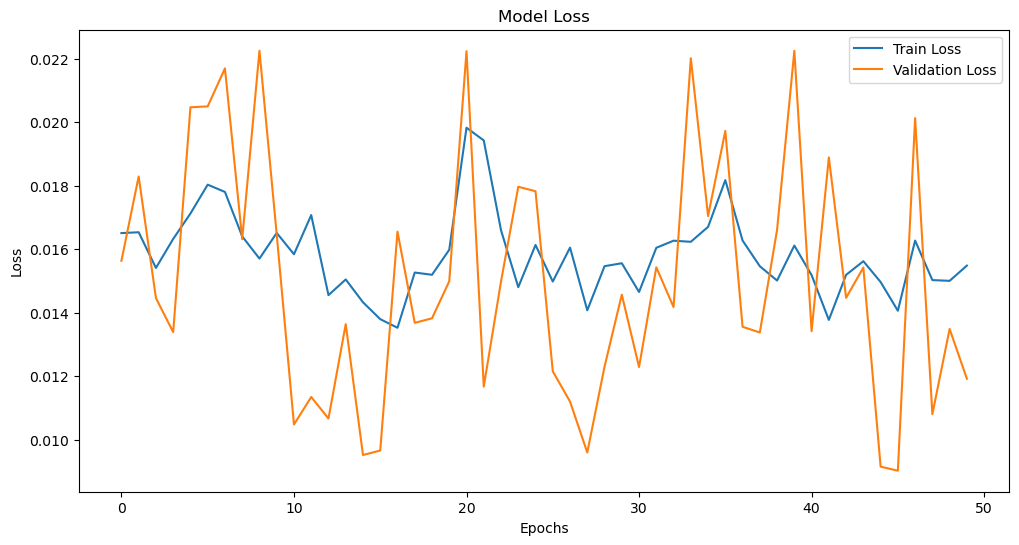

In [ ]:
# Train the model and store the training history
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=32)

# Visualize the training process
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



# Loopa alla subject och gör ett dataset att visa:

In [ ]:
# Antag att test.distanceReference är i meter och representerar ground truth
ground_truth_distance = metadata.distanceReference


print("Predicted distance: ", predicted_distances[-1])
print("Ground truth distance: ", ground_truth_distance)
print("Difference (pred - truth): ", predicted_distances[-1] - ground_truth_distance)


Predicted distance:  614.20435
Ground truth distance:  0      623
1      598
2      584
3      577
4      590
      ... 
198    317
199    365
200    452
201    461
202    517
Name: distanceReference, Length: 203, dtype: int64
Difference (pred - truth):  0       -8.795654
1       16.204346
2       30.204346
3       37.204346
4       24.204346
          ...    
198    297.204346
199    249.204346
200    162.204346
201    153.204346
202     97.204346
Name: distanceReference, Length: 203, dtype: float64


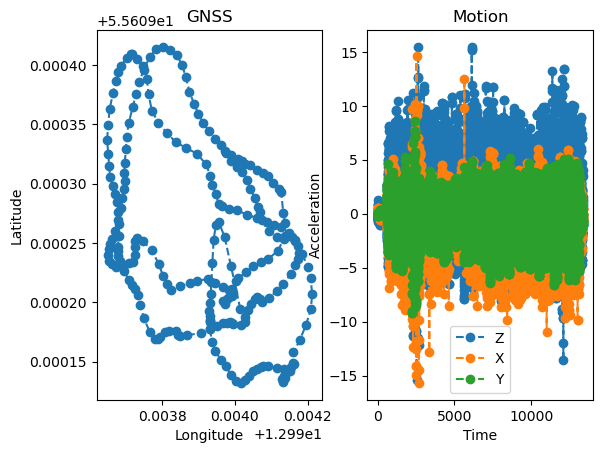

In [ ]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
